In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/bengaluru_house_prices.csv")

In [3]:
# Original dataset
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


count    9243.000000
mean        4.270401
std         0.610662
min         2.302585
25%         3.876085
50%         4.174387
75%         4.574711
max         7.976595
Name: price, dtype: float64


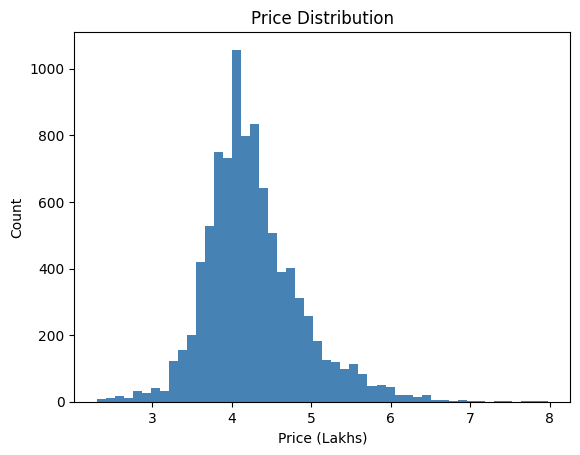

In [25]:
#observing dataset
# Understanding price distribution
print(df['price'].describe())

import matplotlib.pyplot as plt
plt.hist(df['price'], bins=50, color='steelblue')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.title('Price Distribution')
plt.show()

In [4]:
#drop useless column
df.drop(columns = ['area_type','availability','society'],inplace=True)

In [5]:
df

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Richards Town,4 BHK,3600,5.0,NaN,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00


In [6]:
#handle nulls
df.dropna(inplace=True)

In [7]:
#Extract int from BHK
df['BHK'] = df['size'].str.extract(r'(\d+)').astype(int)
df.drop(columns=['size'], inplace=True)

In [8]:
df

,location,total_sqft,bath,balcony,price,BHK
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715,3.0,3.0,112.00,3
13315,Whitefield,3453,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00,2
13318,Padmanabhanagar,4689,4.0,1.0,488.00,4


In [9]:
#handling Ranges values inside total_sqft
def convert_sqft(val):
    if '-' in str(val):
        parts = val.split('-')
        return (float(parts[0]) + float(parts[1])) / 2
    try:
        return float(val)
    except:
        return None
df['total_sqft'] = df['total_sqft'].apply(convert_sqft) 
df.dropna(subset=['total_sqft'], inplace=True)


In [10]:
#cleaned data
df.shape

(12668, 6)

In [11]:
# price outlier removal by price_per_sqft
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [12]:
#unrealistic sqft per BHK removal
df = df[df['total_sqft'] / df['BHK'] >= 300]

In [13]:
#price outliers removal
def remove_price_outlier(df):
    out = []
    for loc,subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        s = subdf['price_per_sqft'].std()
        out.append(subdf[
            (subdf['price_per_sqft']> m-s) &
            (subdf['price_per_sqft']< m+s)
        ])
    return pd.concat(out, ignore_index=True)

df = remove_price_outlier(df)
    

In [14]:
df.drop(columns=['price_per_sqft'], inplace=True)

In [15]:
df.shape

(9243, 6)

In [16]:
# Before OHE
print("Locations before grouping:", df['location'].nunique())

loc_counts = df['location'].value_counts()
df['location'] = df['location'].apply(
    lambda x: x if loc_counts[x] >= 10 else 'other'  #if location count is greater than 10 then only it will be considered
)

print("Locations after grouping:", df['location'].nunique())

Locations before grouping: 759
Locations after grouping: 189


In [17]:
#Dropdown known locations:
known_locations = df[df['location'] != 'other']['location'].unique()
print(f"Total known locations: {len(known_locations)}")
print(sorted(known_locations))

Total known locations: 188
[' Devarachikkanahalli', '1st Phase JP Nagar', '5th Phase JP Nagar', '6th Phase JP Nagar', '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar', 'Abbigere', 'Akshaya Nagar', 'Ambalipura', 'Ambedkar Nagar', 'Amruthahalli', 'Anandapura', 'Ananth Nagar', 'Anekal', 'Anjanapura', 'Ardendale', 'Arekere', 'Attibele', 'BTM 2nd Stage', 'BTM Layout', 'Babusapalaya', 'Balagere', 'Banashankari', 'Banashankari Stage II', 'Banashankari Stage III', 'Banashankari Stage V', 'Banashankari Stage VI', 'Banaswadi', 'Bannerghatta Road', 'Basavangudi', 'Basaveshwara Nagar', 'Battarahalli', 'Begur', 'Begur Road', 'Bellandur', 'Bhoganhalli', 'Billekahalli', 'Binny Pete', 'Bisuvanahalli', 'Bommanahalli', 'Bommasandra', 'Bommasandra Industrial Area', 'Brookefield', 'Budigere', 'CV Raman Nagar', 'Chamrajpet', 'Chandapura', 'Channasandra', 'Chikkalasandra', 'Choodasandra', 'Cunningham Road', 'Dasanapura', 'Dasarahalli', 'Devanahalli', 'Dodda Nekkundi', 'Doddakallasandra', 'Do

In [18]:
#known locations with their count
df[df['location'] != 'other']['location'].value_counts()

location
Whitefield          464
Sarjapur  Road      287
Electronic City     277
Kanakpura Road      187
Uttarahalli         168
                   ... 
LB Shastri Nagar     10
Mico Layout          10
Murugeshpalya        10
Rajiv Nagar          10
Sarakki Nagar        10
Name: count, Length: 188, dtype: int64

In [19]:
df = pd.get_dummies(df, columns=['location'], drop_first=True, dtype=int)

print("shape after OHE: ", df.shape)
print("Total colmuns: ", len(df.columns))

shape after OHE:  (9243, 193)
Total colmuns:  193


In [20]:
df.head()

,total_sqft,bath,balcony,price,BHK,location_1st Phase JP Nagar,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,...,location_Varthur,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yeshwanthpur,location_other
0,1100.0,2.0,1.0,70.0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1672.0,3.0,2.0,150.0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1750.0,3.0,3.0,149.0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1750.0,3.0,2.0,150.0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1250.0,2.0,3.0,44.0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# TRAINING
import numpy as np
df['price'] = np.log(df['price'])  #reducing scale so that model does not act crazy on big price values(luxuries properties)

In [22]:
X = df.drop('price', axis=1)   #features
y = df['price']

In [26]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODEL
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained! Training samples:", len(X_train))

Model trained! Training samples: 7394


In [27]:
# MODEL EVALUATION
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

# Convert back from log scale to actual Lakhs
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

r2   = round(r2_score(y_test, y_pred), 3)               # R² stays on log scale ✅
mae  = round(mean_absolute_error(y_test_actual, y_pred_actual), 2)
rmse = round(np.sqrt(np.mean((y_test_actual - y_pred_actual)**2)), 2)

print(f"R² Score : {r2}")
print(f"MAE      : ₹{mae} Lakhs")
print(f"RMSE     : ₹{rmse} Lakhs")

R² Score : 0.826
MAE      : ₹18.75 Lakhs
RMSE     : ₹49.2 Lakhs


In [28]:
import pickle, json

with open('../model/house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../model/columns.json', 'w') as f:
    json.dump({"data_columns": list(X.columns)}, f)

print("Saved!")

Saved!
